In [2]:
#%cd /teamspace/studios/this_studio/Physics-Informed-Neural-Networks-for-Synchronous-Machine-Models

import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd 
import os
from src.nn.nn_dataset import DataSampler
from src.functions import *
from src.nn.nn_actions import NeuralNetworkActions
from src.ode.sm_models_d import SynchronousMachineModels
from src.nn.nn_inference import *

%load_ext autoreload
%autoreload 2

from omegaconf import OmegaConf
import wandb
import time


In [3]:
cfg = OmegaConf.load("src/conf/setup_dataset_nn.yaml")
##### Change modelling here is needed #####
# set seed = 3
cfg.time = 1
#cfg.model.model_flag ="SM6"
cfg.seed = 3
modelling_full = SynchronousMachineModels(cfg)
data_network = NeuralNetworkActions(cfg, modelling_full)
device = data_network.device
input_dim = data_network.data_loader.input_dim
print("The total number of test trajectories is: ", int(len(data_network.data_loader.x_test) / data_network.data_loader.sample_per_traj))
output_dim = input_dim - 1 
sample_per_traj = cfg.num_of_points

starting_traj = 0
total_traj = 200
x_test = data_network.data_loader.x_test[starting_traj*sample_per_traj:(starting_traj+total_traj)*sample_per_traj].clone().detach().to(data_network.device).requires_grad_(True)
y_test = data_network.data_loader.y_test[starting_traj*sample_per_traj:(starting_traj+total_traj)*sample_per_traj].clone().detach().to(data_network.device)
x_test_one_traj = data_network.data_loader.x_test[starting_traj*sample_per_traj:(starting_traj+1)*sample_per_traj].clone().detach().to(data_network.device).requires_grad_(True)

#### THE WHOLE DATASET ####
#x_test = data_network.data_loader.x.clone().detach().to(data_network.device).requires_grad_(True)
#y_test = data_network.data_loader.y.clone().detach().to(data_network.device)
print("The current test will contain ",  int(len(x_test) / data_network.data_loader.sample_per_traj), " trajectories")

folders = ["data_dt_pinn_ic"]
files = find_files(cfg, folders, [cfg.model.model_flag,"Static","KAN"])
print(files)


SM_AVR_GOV data
Loading data from:  ./data/SM_AVR_GOV/dataset_v4.pkl


c:\Users\Giannis\Desktop\Thesis\Physics-Informed-Neural-Networks-for-Synchronous-Machine-Models\src\nn\nn_dataset.py:186: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ..\torch\csrc\utils\tensor_new.cpp:264.)
  training_sample = torch.tensor(training_sample, dtype=torch.float32) # convert the trajectory to tensor


Number of training samples:  400000 Number of validation samples:  50000 Number of testing samples:  50000
Number of different initial conditions for collocation points:  500
['theta', 'omega', 'E_d_dash', 'E_q_dash', 'R_F', 'V_r', 'E_fd', 'P_sv', 'P_m'] Variables
[[-2, 2], [-1, 1], [0], [0.9, 1.1], [1], [1.105], [1.08], [0.7048], [0.7048]] Set of values for init conditions
[10, 10, 1, 5, 1, 1, 1, 1, 1] Iterations per value
Selected deep learning model:  KAN
10 14 9
checkpoint directory created: ./model
saving model version 0.0
The total number of test trajectories is:  50
The current test will contain  50  trajectories
Files found 1
['data_dt_pinn_ic\\SM_AVR_GOVKAN_1_375_17392_26316_12500_None_None_1_0.001_0.0001_0.001_Static.pth']


SM_AVR_GOV
data_dt_pinn_ic\SM_AVR_GOVKAN_1_375_17392_26316_12500_None_None_1_0.001_0.0001_0.001_Static.pth
Selected deep learning model:  KAN
checkpoint directory created: ./model
saving model version 0.0
Total number of trainable parameters:  8778
Mean time for 50 traj 0.025896661281585694 std time for 50 traj 0.030352292165429957 Mean time for 1 traj 0.00965423345565796 std time for 1 traj 0.0026140109506328285
Total time for 50 traj 0.025896661281585694 total time for 1 traj 0.00965423345565796 trainable parameters  8778
Model and nn type already in file


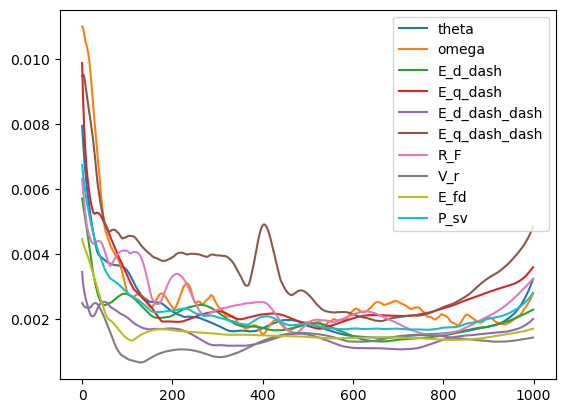

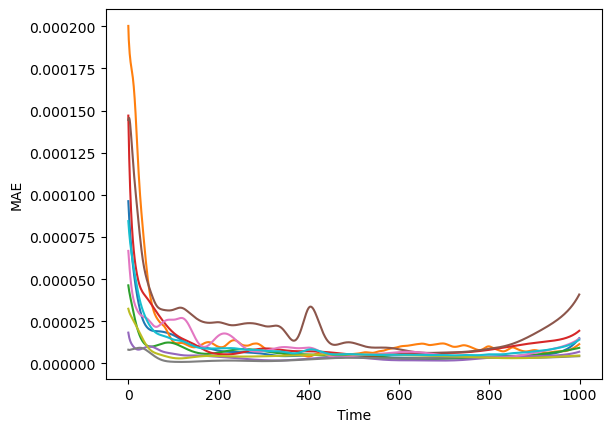

In [5]:
mse = []
mae = []
num = 0

for name in files:
    if check_transform(name):
        pass
    elif check_sm_modelling(name, cfg):
        pass
    else:
        print(name)
        cfg.nn.type = define_model_from_name(name) 
        if cfg.nn.type == "KAN":
            cfg.nn.hidden_layers = 2
            cfg.nn.hidden_dim = 14
        else:
            cfg.nn.hidden_layers = 4
            cfg.nn.hidden_dim = 64
        model = define_nn_model(cfg, input_dim, output_dim)
        model.to(device)
        # set model to test mode
        model.eval()
        # find all the trainable parameters of model
        total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print("Total number of trainable parameters: ", total_trainable_params)
        #print(name)
        load_model(model, cfg, name)
        
        iterations = 100
        start = time.time()
        start_per_iteration = start
        timing = []
        for i in range(iterations):
            y_pred = forward_pass(model, data_network, x_test )
            end_per_iteration = time.time()
            timing.append(end_per_iteration-start_per_iteration)
            start_per_iteration = end_per_iteration
        end = time.time()
        start_one = time.time()
        start_one_per_iteration = start_one
        timing_one = []
        for i in range(iterations):
            y_pred_one_traj = forward_pass(model, data_network, x_test_one_traj )
            end_one_per_iteration = time.time()
            timing_one.append(end_one_per_iteration-start_one_per_iteration)
            start_one_per_iteration = end_one_per_iteration
        end_one = time.time()
        mse.append(data_network.criterion(y_pred, y_test).item())
        mae.append(data_network.criterion_mae(y_pred, y_test).item())
        total_time = (end-start)/iterations
        total_time_one = (end_one-start_one)/iterations
        #print mean and std of timing
        print("Mean time for 50 traj", np.mean(timing), "std time for 50 traj", np.std(timing), "Mean time for 1 traj", np.mean(timing_one), "std time for 1 traj", np.std(timing_one))
        print("Total time for 50 traj",total_time, "total time for 1 traj", total_time_one, "trainable parameters ", total_trainable_params)
        save_results(cfg.model.model_flag, cfg.nn.type, timing, timing_one)
        mae_in_time, mse_in_time, max_ae_in_time = loss_over_time(x_test, y_test, y_pred)
        path_mae = "paper/" + cfg.model.model_flag + "_"+ cfg.nn.type + "_"+"mae"
        path_mse = "paper/" + cfg.model.model_flag + "_"+ cfg.nn.type + "_"+"mse"
        path_max_ae = "paper/" + cfg.model.model_flag + "_"+ cfg.nn.type + "_"+"max_ae"
        keys = variable_names(cfg)
        save_as_dat(mae_in_time, x_test, keys, path_mae)
        save_as_dat(mse_in_time, x_test, keys, path_mse)
        save_as_dat(max_ae_in_time, x_test, keys, path_max_ae)
        path_var_samples_pred = "paper/samples/" + cfg.model.model_flag + "_"+ cfg.nn.type + "_"+"pred_samples_"
        save_as_dat_per_var(y_pred, x_test, cfg.num_of_points, keys, path_var_samples_pred)
        path_var_samples_y_true = "paper/samples/" + cfg.model.model_flag + "_"+"y_true_samples_"
        save_as_dat_per_var(y_test, x_test, cfg.num_of_points, keys, path_var_samples_y_true)
        names = ["theta", "omega", "E_d_dash", "E_q_dash", "E_d_dash_dash", "E_q_dash_dash", "R_F", "V_r", "E_fd", "P_sv", "P_m"]
        # add labels to the plot
        # plot all the mae_in_time with the respective labels
        for i in range(len(mae_in_time[0])):
            plt.plot(mae_in_time[:,i], label=names[i])
        plt.legend()
        plt.show()
        plt.xlabel("Time")
        plt.ylabel("MAE")

        plt.plot(mse_in_time)
        plt.show()
        
        



In [87]:
#find max in metrics

metrics.max()

0.04694950580596924

In [86]:
metrics = loss_in_time(x_test, y_test, y_pred)
path_metrics = "paper/" + cfg.model.model_flag + "_"+ cfg.nn.type + "_"+"metrics"
keys = ["mae", "mse", "max_ae"]
save_as_dat_in_time(metrics, x_test, keys, path_metrics)

In [45]:
sorted_mae, sorted_names = sort_by_loss(mae,files)
sorted_mae, sorted_mse = sort_by_loss(mae,mse)
for i in range(len(sorted_mae)):
    print(sorted_mae[i], sorted_mse[i], sorted_names[i])

0.001528026070445776 4.8891220103541855e-06 data_dt_pinn_ic\SM6DynamicNN_1_553_17392_26316_12500_None_None_1_0.001_0.0001_0.001_Static.pth
0.001699437852948904 6.294217200775165e-06 data_dt_pinn_ic\SM6KAN_1_300_17392_26316_12500_None_None_1_0.001_0.0001_0.001_Static.pth


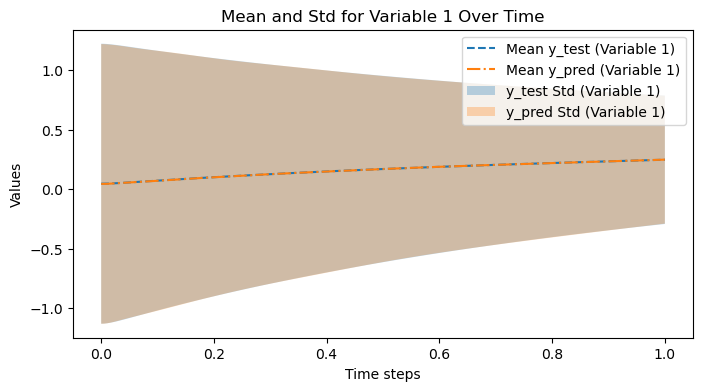

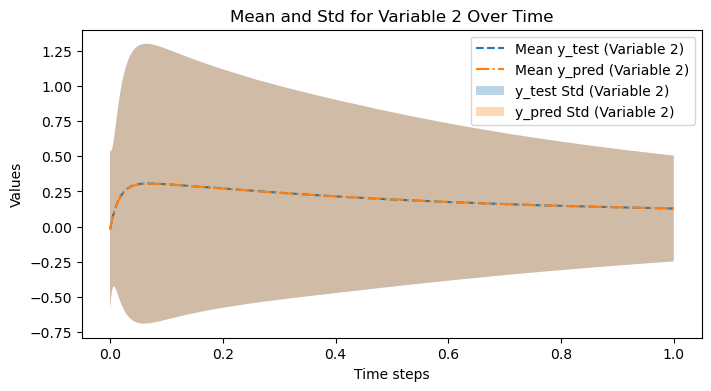

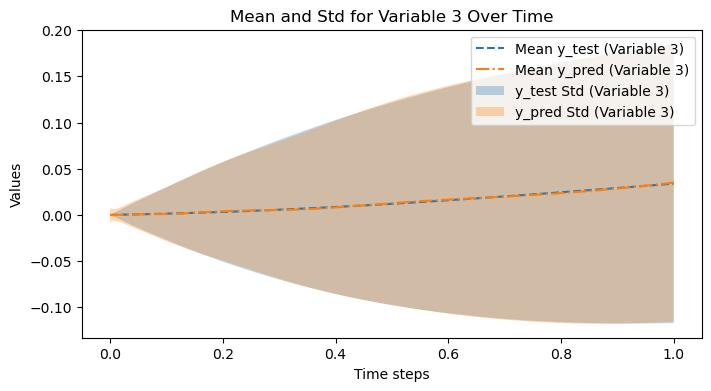

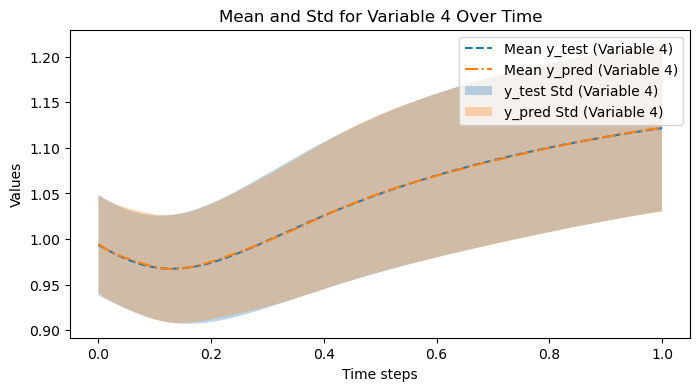

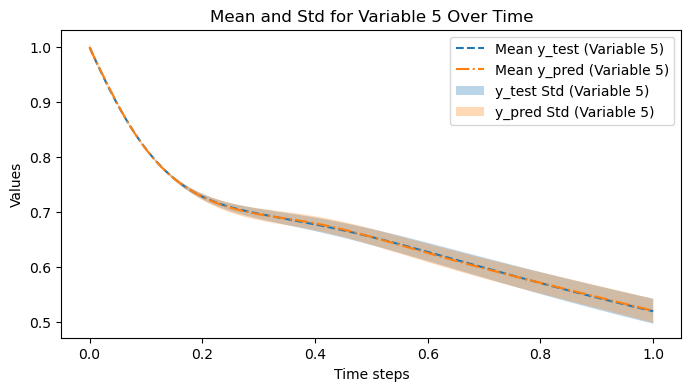

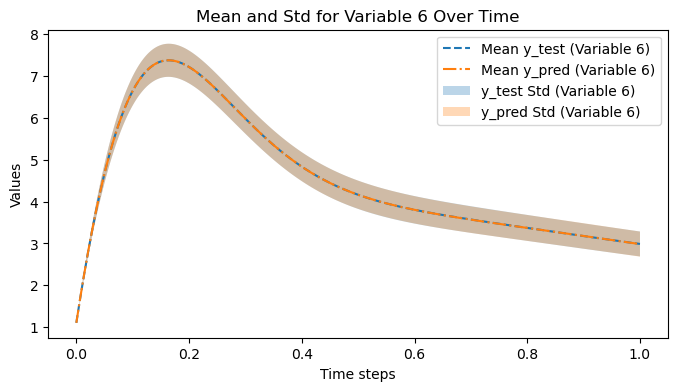

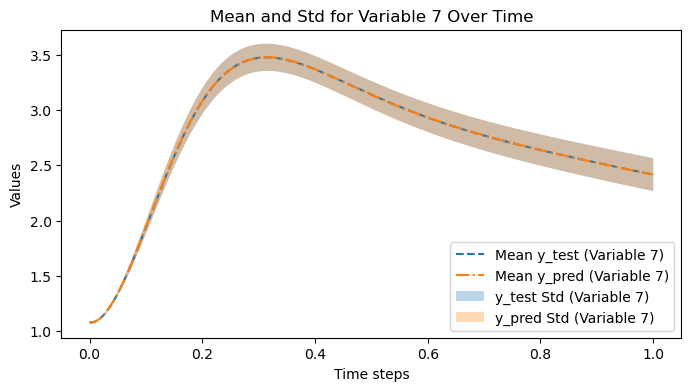

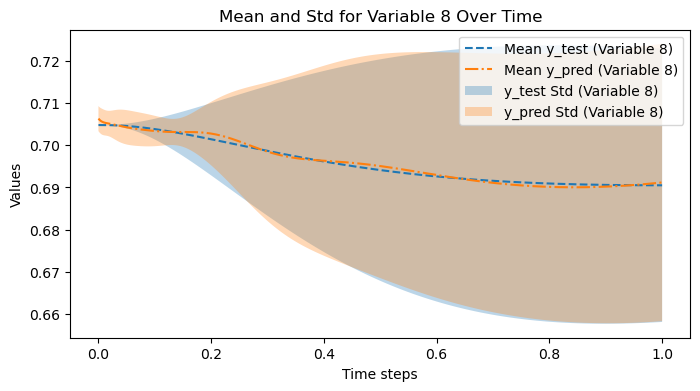

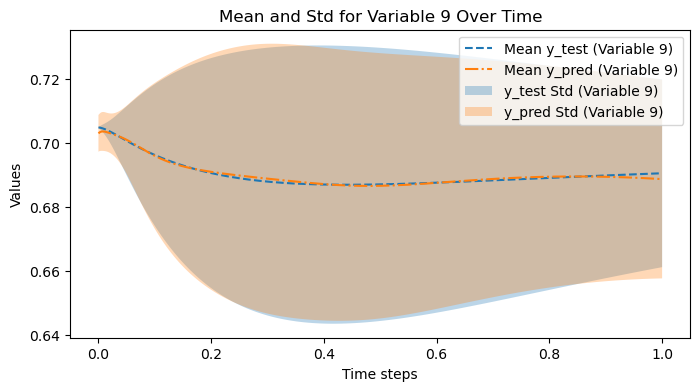

In [ ]:
# I want to create a plot with y_test where at each time step you plot the mean and std of the prediction 

def max_mae_over_time(x_test, y_test, y_pred):
    unique_values = torch.unique(x_test[:, 0])  # get the unique values of the time
    mae2 = torch.abs(y_test - y_pred)

    max_mae = []
    for value in unique_values:  # for each time step
        index = torch.where(x_test[:, 0] == value)  # find the indexes of the time step
        mae2_ = mae2[index]  # keep only the points at the specific time
        max_mae.append(torch.max(mae2_, dim=0).values.tolist())
        

def plot_mean_std(y_pred, y_test, x_test):

    unique_values = torch.unique(x_test[:, 0])  # get the unique values of the time
    mean_y_test = []
    mean_y_pred = []
    std_y_test = []
    std_y_pred = []

    for value in unique_values:  # for each time step
        index = torch.where(x_test[:, 0] == value)  # find the indexes of the time step
        y_true = y_test[index]  # keep only the points at the specific time
        y_pred_ = y_pred[index]  # keep only the points at the specific time
        
        # Calculate mean and std
        mean_y_test.append(torch.mean(y_true, dim=0).tolist())
        mean_y_pred.append(torch.mean(y_pred_, dim=0).tolist())
        std_y_test.append(torch.std(y_true, dim=0).tolist())
        std_y_pred.append(torch.std(y_pred_, dim=0).tolist())

    mean_y_test = np.array(mean_y_test)
    mean_y_pred = np.array(mean_y_pred)
    std_y_test = np.array(std_y_test)
    std_y_pred = np.array(std_y_pred)
    time_steps = unique_values.cpu().numpy()

    # Plotting mean and std for each variable
    num_variables = mean_y_test.shape[1]
    for i in range(num_variables):
        plt.figure(figsize=(8, 4))
        
        # Plot mean
        plt.plot(time_steps, mean_y_test[:, i], label=f"Mean y_test (Variable {i+1})", linestyle="--")
        plt.plot(time_steps, mean_y_pred[:, i], label=f"Mean y_pred (Variable {i+1})", linestyle="-.")
        
        # Plot std as shaded area
        plt.fill_between(
            time_steps,
            mean_y_test[:, i] - std_y_test[:, i],
            mean_y_test[:, i] + std_y_test[:, i],
            alpha=0.3,
            label=f"y_test Std (Variable {i+1})",
        )
        plt.fill_between(
            time_steps,
            mean_y_pred[:, i] - std_y_pred[:, i],
            mean_y_pred[:, i] + std_y_pred[:, i],
            alpha=0.3,
            label=f"y_pred Std (Variable {i+1})",
        )
        
        plt.xlabel("Time steps")
        plt.ylabel("Values")
        plt.title(f"Mean and Std for Variable {i+1} Over Time")
        plt.legend()
        plt.show()

# Example call
# plot_mean_std(x_test, y_test, y_pred)

num_of_points = 50000000
y_pred_ = y_pred[:num_of_points].detach().cpu()
y_test_ = y_test[:num_of_points].detach().cpu()
x_test_ = x_test[:num_of_points].detach().cpu()
plot_mean_std(y_pred_, y_test_, x_test_)

In [55]:
y_test[:5000000:1000,0].shape

torch.Size([500])

In [60]:
y_test[:5000000:1000,1].max()

tensor(0.8745, device='cuda:0')

In [ ]:
#find_min_loss(mse,files)
#find_min_loss(mae,files)

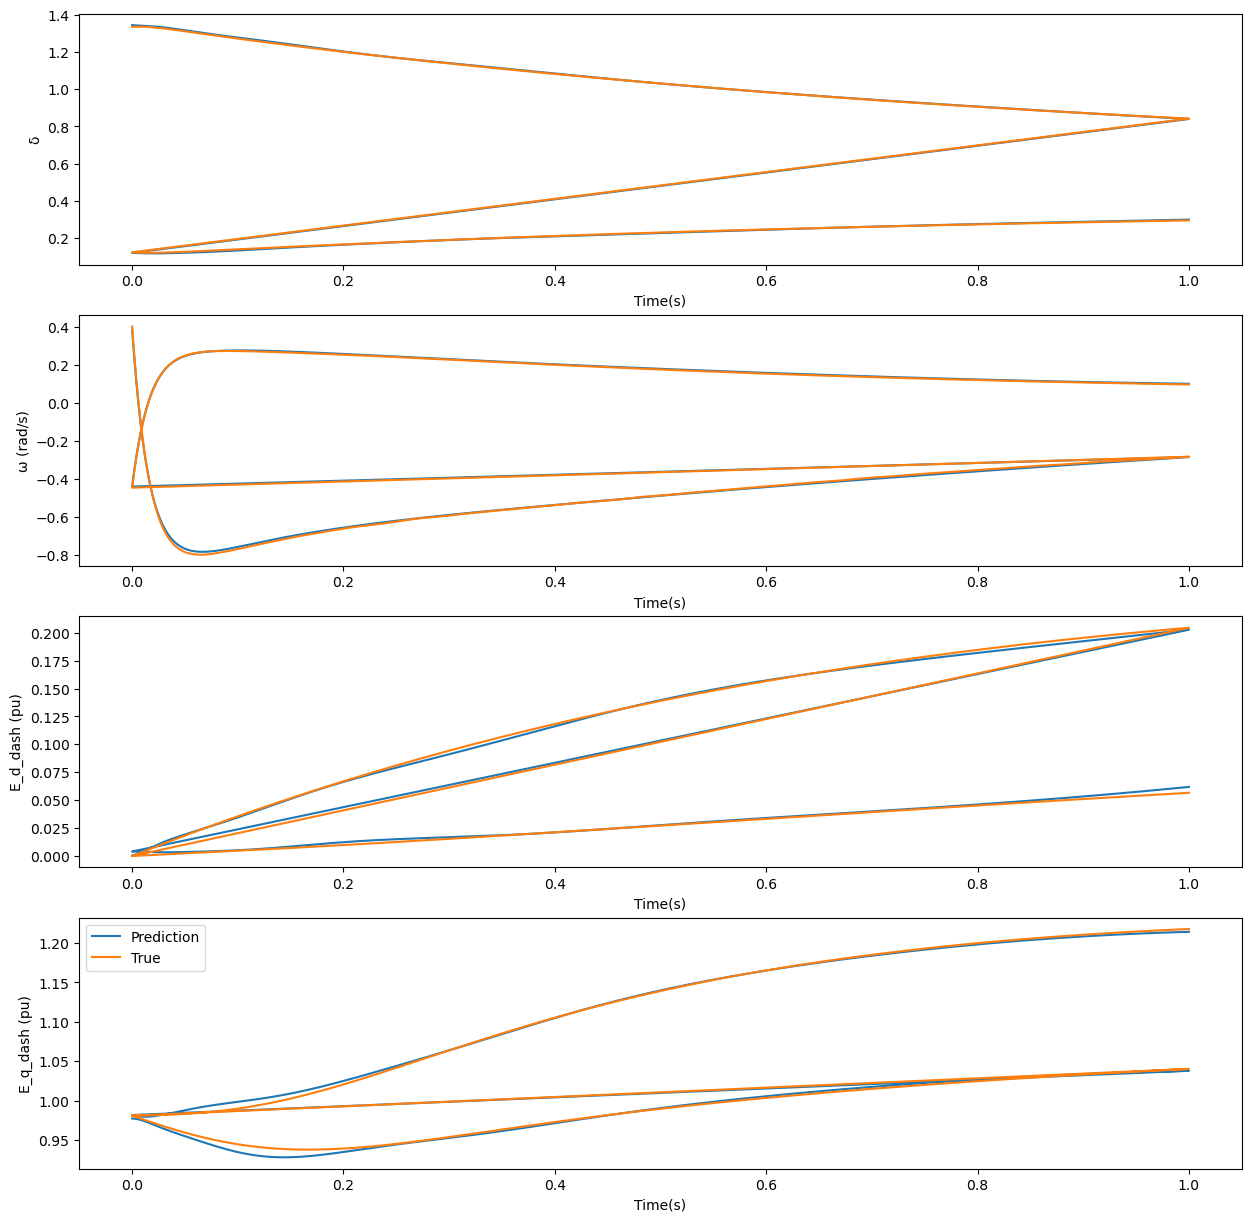

In [35]:
plot_results(y_pred, y_test, x_test, 2000)

In [ ]:

unique_values = torch.unique(x_test[:,0])
# for each unique value, plot the prediction and the true value

mae = []
rmse = []
for value in unique_values:
    index = torch.where(x_test[:,0] == value)
    # calculate the mae and rmse for each value
    y_pred_ = list_of_preds[0][index]
    y_true = y_test[index]
    mae_var = []
    rmse_var = []
    for i in range(y_pred_.shape[1]):
        mae_var.append(data_network.criterion_mae(y_pred_[i], y_true[i]).detach().item())
        rmse_var.append(data_network.criterion(y_pred_[i], y_true[i]).detach().item())
    mae.append((mae_var))
    rmse.append((rmse_var))
mae = np.array(mae)
rmse = np.array(rmse)



In [ ]:
x_train = data_network.data_loader.x_train.clone().detach().to(data_network.device).requires_grad_(True)
x_trainz_step = x_train[::23].clone().detach().to(data_network.device).requires_grad_(True)
x_trainz_step.shape

# make a histogram of the x_trainz_step[:,0] values

plt.hist(x_trainz_step[:,0].cpu().detach().numpy(), bins=100)
plt.show()

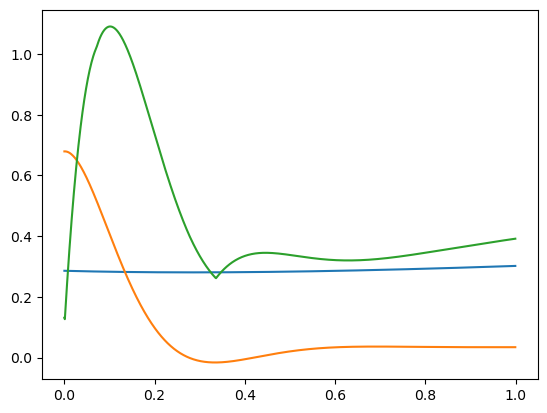

In [93]:
len(mae)

# from the list mae that has 1000 elements, and each element has 4 elements, I want to get the plot of only one element of the 4 elements

mae = np.array(mae)
rmse = np.array(rmse)

mae.shape

var = 0
plt.plot(unique_values.detach().cpu().numpy(),y_pred[:1000,var].detach().cpu().numpy())
plt.plot(unique_values.detach().cpu().numpy(),y_test[:1000,var].detach().cpu().numpy())
plt.plot(unique_values.detach().cpu().numpy(),mae[:,var])

In [85]:
y_pred.shape

torch.Size([49, 4])

In [ ]:
files[0]

# split this text 'data_dt\\GiannisSMDynamicNN_10000_19802_133334_16667_1_0.0001_0.pth' to get the parameters
# first split by \\ and then by _
split = [files[0].split("\\")[-1]]
# split by _
splitn = split[0].split("_")
# name = f"{self.cfg.model.model_flag}{self.cfg.nn.type}_{self.cfg.time}_{epoch+1}_{self.training_shape}_{self.training_col_shape}_{self.validation_shape}_{self.cfg.dataset.transform_input}_{self.cfg.dataset.transform_output}_{weight_data}_{weight_dt}_{weight_pinn}_{self.cfg.nn.update_weight_method}.pth"

# create a mapping for the parameters
mapping = {
    "model_flag": splitn[0],
    "nn_type": splitn[1],
    "time": splitn[2],
    "epoch": splitn[3],
    "training_shape": splitn[4],
    "training_col_shape": splitn[5],
    "validation_shape": splitn[6],
    "transform_input": splitn[7],
    "transform_output": splitn[8],
    "weight_data": splitn[9],
    "weight_dt": splitn[10],
    "weight_pinn": splitn[11],
    "update_weight_method": splitn[12]
}
mapping

In [61]:
mae, rmse = model.loss_over_time(x_test, y_test, y_pred, run=None) #Simantiko


AttributeError: 'Network' object has no attribute 'loss_over_time'